# Equal-edge matched-weights heatmap

This notebook generates panel A-D of Appendix Figure 1, as well as an additional heatmap including all values of $n$. 
It computes the expected cost difference between the caterpillar and its NNI cherry-caterpillar neighbor, caches the grid in `cached_data/`, and writes the four figure panels to a single multi-page PDF. 

In [ ]:
# ── Recompute flags ───────────────────────────────────────────────────────────
FORCE_RECOMPUTE = False

# ── Analysis parameters ───────────────────────────────────────────────────────
N_GRID    = 25
N_VALUES  = list(range(4, 10))   # n values for T1/T2 comparison
N_VALUES_T3 = list(range(5, 10)) # n values for T2/T3 comparison (T3 requires n >= 5)

# ── Output paths ──────────────────────────────────────────────────────────────
MULTIPAGE_FIGURE_PATH = "../figures/Equal_edge_lengths.pdf"

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

In [3]:
cwd = Path.cwd().resolve()
src_candidates = [cwd / "src", cwd.parent / "src", cwd.parent.parent / "src"]
SRC_DIR = next((c for c in src_candidates if c.exists()), None)
if SRC_DIR is None:
    raise RuntimeError("Could not infer the src directory from the current working directory.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from inconsistency_generation.repo_paths import get_repo_root
from inconsistency_generation.equal_edge_analysis import (
    caterpillar_splits,
    nni_cherry_caterpillar_splits,
    three_leaf_subtree_splits,
    expected_cost_given_edge,
    load_or_compute_heatmaps,
    default_analyses,
    default_t2_t3_analyses,
)
from inconsistency_generation.equal_edge_plots import (
    plot_example_topologies,
    plot_heatmap_panel,
    plot_area_by_n_figure,
    plot_all_directions_area,
    plot_combined_heatmap,
)

REPO_ROOT = get_repo_root(cwd)
CACHE_DIR = REPO_ROOT / "cached_data"
FIGURES_DIR = REPO_ROOT / "figures"
CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 150

ALPHA_VALS = np.linspace(0.01, 0.499, N_GRID)
BETA_VALS  = np.linspace(0.01, 0.499, N_GRID)
ANALYSES      = default_analyses(CACHE_DIR)
ANALYSES_T2_T3 = default_t2_t3_analyses(CACHE_DIR)
MULTIPAGE_FIGURE_PATH = FIGURES_DIR / MULTIPAGE_FIGURE_PATH

## Example topologies

The exact example trees, with one dashed edge indicating continuation of the caterpillar side.

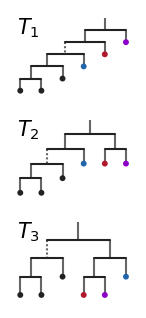

In [4]:
plot_example_topologies(n=6)

## Compute expected value grid

Running the analysis for up to $n=10$ should take 6-10 minutes on a laptop. Results will be cached and stored in `cached_data`. If precomputed values exist, the cached values will be used unless `force_recompute` is true. 

In [5]:
analysis_results = {}
for analysis in ANALYSES:
    analysis_results[analysis["name"]] = load_or_compute_heatmaps(
        analysis=analysis,
        alpha_vals=ALPHA_VALS,
        beta_vals=BETA_VALS,
        n_values=N_VALUES,
        force_recompute=FORCE_RECOMPUTE,
    )

Loaded caterpillar_minus_cherry_cat from equal_edges_matched_weights_caterpillar_minus_cherry_cat_data.npz
Loaded cherry_cat_minus_caterpillar from equal_edges_matched_weights_cherry_cat_minus_caterpillar_data.npz


In [6]:
t2_t3_results = {}
for analysis in ANALYSES_T2_T3:
    t2_t3_results[analysis["name"]] = load_or_compute_heatmaps(
        analysis=analysis,
        alpha_vals=ALPHA_VALS,
        beta_vals=BETA_VALS,
        n_values=N_VALUES_T3,
        force_recompute=FORCE_RECOMPUTE,
    )

Loaded cherry_cat_minus_three_leaf from equal_edges_matched_weights_cherry_cat_minus_three_leaf_data.npz
Loaded three_leaf_minus_cherry_cat from equal_edges_matched_weights_three_leaf_minus_cherry_cat_data.npz


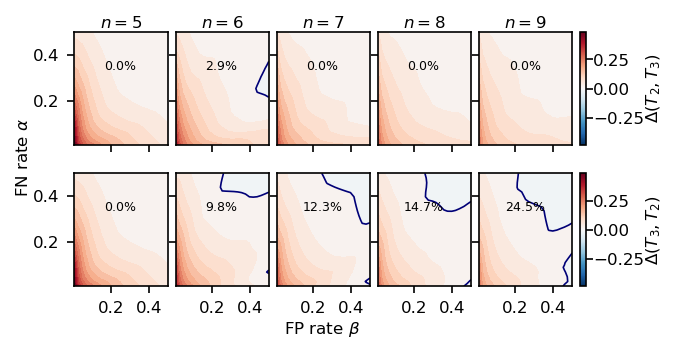

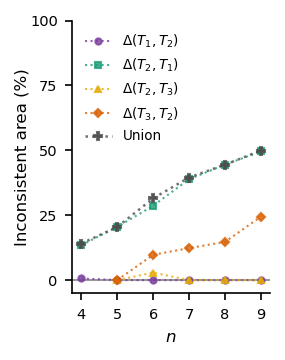

In [7]:
plot_heatmap_panel(t2_t3_results, ANALYSES_T2_T3, N_VALUES_T3, figsize=(4.4, 2.2))
plot_all_directions_area(
    analysis_results, t2_t3_results, ANALYSES, ANALYSES_T2_T3,
    N_VALUES, N_VALUES_T3, ALPHA_VALS, BETA_VALS,
)

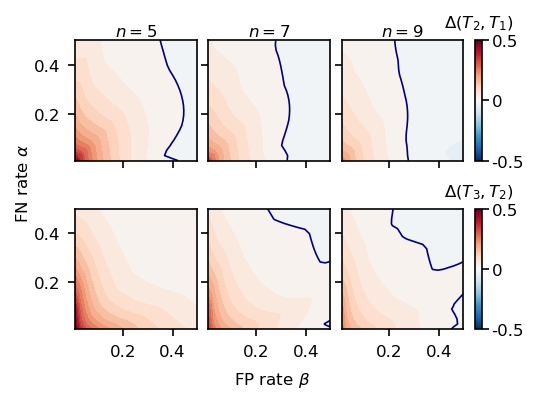

In [8]:
plot_combined_heatmap(analysis_results, t2_t3_results, ALPHA_VALS)

In [9]:
with PdfPages(MULTIPAGE_FIGURE_PATH) as pdf:
    plot_example_topologies(n=6, pdf=pdf, show=False)
    plot_all_directions_area(
        analysis_results, t2_t3_results, ANALYSES, ANALYSES_T2_T3,
        N_VALUES, N_VALUES_T3, ALPHA_VALS, BETA_VALS, pdf=pdf, show=False,
    )
    plot_combined_heatmap(analysis_results, t2_t3_results, ALPHA_VALS, pdf=pdf, show=False)
print(f"Saved {MULTIPAGE_FIGURE_PATH}")

Saved /Users/satasg/Documents/repos/inconsistency_repo/figures/../figures/FigureA1_equal_edge_weights_panels.pdf
